In [32]:
%pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [98]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator

In [99]:
from matplotlib.ticker import FuncFormatter

percent_formatter = FuncFormatter(
    lambda value, position: f"{value:.0f}%"
)

seconds_formatter = FuncFormatter(
    lambda value, position: f"{value:.2f} s"
)

accuracy_formatter = FuncFormatter(
    lambda value, position: f"{value:.1f}%"
)

percentage_point_formatter = FuncFormatter(
    lambda value, position: f"{value:.1f} pp"
)

In [100]:
DATA_FOLDER = Path("data")

if not DATA_FOLDER.exists():
    raise FileNotFoundError(
        "The data folder was not found. "
        "Make sure the notebook is inside the main I-Max project folder."
    )

print("Data folder found:", DATA_FOLDER.resolve())

Data folder found: C:\Users\Ivan\Desktop\DLSU\Subjects\COLLEGE YEAR 3\TERM3\NSDSYST\Final MP\Imax-Instance-Searching-main\data


In [101]:
def load_result_file(file_path):
    """
    Reads one I-Max JSON result file and converts all worker results
    into one table sorted from 5% to 100%.
    """

    with file_path.open("r", encoding="utf-8") as file:
        results = json.load(file)

    rows = []

    for worker_name, worker_results in results.items():
        for subset, measurement in worker_results.items():
            rows.append({
                "worker": worker_name,
                "subset": int(subset),
                "duration": float(measurement["duration"]),
                "accuracy": float(measurement["score"]) * 100
            })

    result_df = pd.DataFrame(rows)

    if result_df.empty:
        raise ValueError(f"No experiment results found in {file_path.name}")

    result_df = (
        result_df
        .sort_values("subset")
        .reset_index(drop=True)
    )

    return result_df

In [102]:
result_files = sorted(
    DATA_FOLDER.glob("imax_results_[0-9]*.json"),
    key=lambda path: int(path.stem.split("_")[-1])
)

print("Numbered result files found:", len(result_files))

for file_path in result_files:
    print(file_path.name)

Numbered result files found: 10
imax_results_1.json
imax_results_2.json
imax_results_3.json
imax_results_4.json
imax_results_5.json
imax_results_6.json
imax_results_7.json
imax_results_8.json
imax_results_9.json
imax_results_10.json


In [103]:
expected_subsets = list(range(5, 101, 5))

for file_path in result_files:
    run_df = load_result_file(file_path)
    actual_subsets = run_df["subset"].tolist()

    if actual_subsets == expected_subsets:
        print(f"{file_path.name}: PASS — all 20 subsets found")
    else:
        print(f"{file_path.name}: FAIL")
        print("Found:", actual_subsets)

imax_results_1.json: PASS — all 20 subsets found
imax_results_2.json: PASS — all 20 subsets found
imax_results_3.json: PASS — all 20 subsets found
imax_results_4.json: PASS — all 20 subsets found
imax_results_5.json: PASS — all 20 subsets found
imax_results_6.json: PASS — all 20 subsets found
imax_results_7.json: PASS — all 20 subsets found
imax_results_8.json: PASS — all 20 subsets found
imax_results_9.json: PASS — all 20 subsets found
imax_results_10.json: PASS — all 20 subsets found


In [104]:
summary_rows = []

for file_path in result_files:
    iteration = int(file_path.stem.split("_")[-1])
    run_df = load_result_file(file_path)

    knee = KneeLocator(
        run_df["duration"],
        run_df["accuracy"],
        curve="concave",
        direction="increasing"
    )

    if knee.knee is None:
        print(f"Warning: No knee detected for Run {iteration}")
        continue

    # Find the result whose duration is closest to the detected knee.
    optimal_index = (
        run_df["duration"] - knee.knee
    ).abs().idxmin()

    optimal_row = run_df.loc[optimal_index]

    summary_rows.append({
        "iteration": iteration,
        "optimal_subset": int(optimal_row["subset"]),
        "duration": float(optimal_row["duration"]),
        "accuracy": float(optimal_row["accuracy"]),
        "worker": optimal_row["worker"]
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("iteration")
    .reset_index(drop=True)
)

summary_df

,iteration,optimal_subset,duration,accuracy,worker
0,1,10,0.142992,92.607174,worker4
1,2,5,0.102946,92.519685,worker0
2,3,5,0.104391,92.519685,worker1
3,4,25,0.224452,92.825897,worker2
4,5,10,0.132724,92.607174,worker3
5,6,10,0.124442,92.607174,worker3
6,7,5,0.101213,92.519685,worker1
7,8,5,0.118192,92.519685,worker1
8,9,5,0.107982,92.519685,worker1
9,10,10,0.137370,92.607174,worker3


In [105]:
display_df = summary_df.copy()

display_df["optimal_subset"] = (
    display_df["optimal_subset"].astype(str) + "%"
)

display_df["duration"] = (
    display_df["duration"]
    .map(lambda value: f"{value:.6f} seconds")
)

display_df["accuracy"] = (
    display_df["accuracy"]
    .map(lambda value: f"{value:.4f}%")
)

display_df = display_df.rename(columns={
    "iteration": "Run",
    "optimal_subset": "Selected Subset",
    "duration": "Processing Time",
    "accuracy": "Accuracy",
    "worker": "Worker"
})

display_df

,Run,Selected Subset,Processing Time,Accuracy,Worker
0,1,10%,0.142992 seconds,92.6072%,worker4
1,2,5%,0.102946 seconds,92.5197%,worker0
2,3,5%,0.104391 seconds,92.5197%,worker1
3,4,25%,0.224452 seconds,92.8259%,worker2
4,5,10%,0.132724 seconds,92.6072%,worker3
5,6,10%,0.124442 seconds,92.6072%,worker3
6,7,5%,0.101213 seconds,92.5197%,worker1
7,8,5%,0.118192 seconds,92.5197%,worker1
8,9,5%,0.107982 seconds,92.5197%,worker1
9,10,10%,0.137370 seconds,92.6072%,worker3


In [106]:
frequency = (
    summary_df["optimal_subset"]
    .value_counts()
    .sort_index()
)

small_subset_runs = (
    summary_df["optimal_subset"] <= 10
).sum()

small_subset_percentage = (
    small_subset_runs / len(summary_df)
) * 100

print("Optimal subset frequency:")

for subset, count in frequency.items():
    print(f"{subset}% selected in {count} run(s)")

print()
print(
    f"{small_subset_runs} out of {len(summary_df)} runs "
    f"selected 10% or less."
)

print(
    f"Percentage selecting 10% or less: "
    f"{small_subset_percentage:.0f}%"
)

print(
    f"Average selected processing time: "
    f"{summary_df['duration'].mean():.6f} seconds"
)

print(
    f"Average selected accuracy: "
    f"{summary_df['accuracy'].mean():.4f}%"
)

Optimal subset frequency:
5% selected in 5 run(s)
10% selected in 4 run(s)
25% selected in 1 run(s)

9 out of 10 runs selected 10% or less.
Percentage selecting 10% or less: 90%
Average selected processing time: 0.129670 seconds
Average selected accuracy: 92.5853%


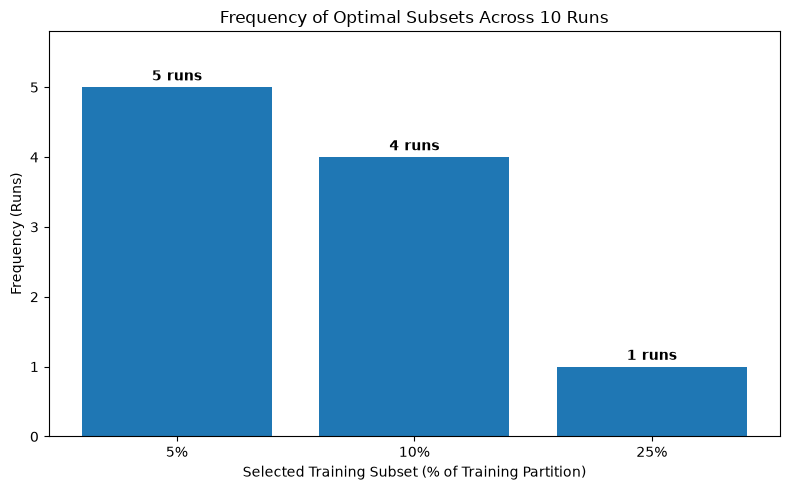

In [107]:
frequency = (
    summary_df["optimal_subset"]
    .value_counts()
    .sort_index()
)

labels = [f"{subset}%" for subset in frequency.index]
values = frequency.values

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value} runs",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title("Frequency of Optimal Subsets Across 10 Runs")
plt.xlabel("Selected Training Subset (% of Training Partition)")
plt.ylabel("Frequency (Runs)")
plt.yticks(range(0, int(max(values)) + 1))
plt.ylim(0, max(values) + 0.8)
plt.tight_layout()

plt.savefig(
    DATA_FOLDER / "optimal_subset_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

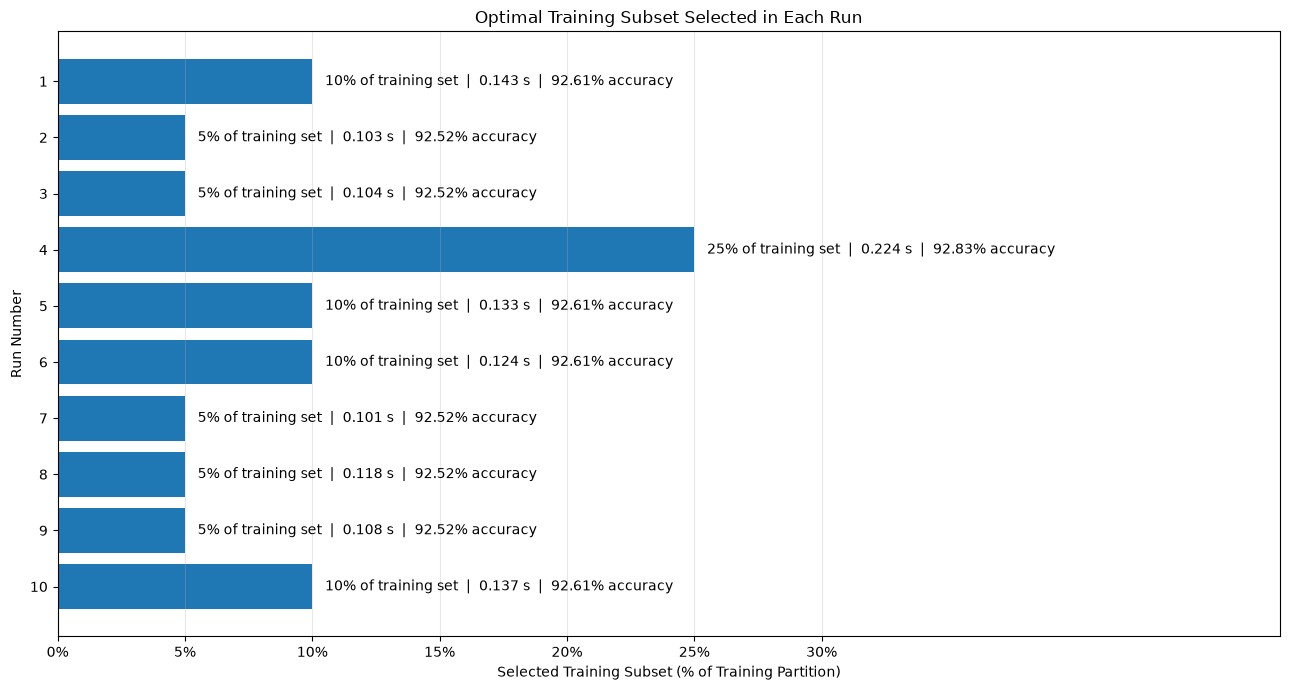

In [108]:
plot_df = summary_df.sort_values("iteration")

plt.figure(figsize=(13, 7))

bars = plt.barh(
    plot_df["iteration"].astype(str),
    plot_df["optimal_subset"]
)

for bar, row in zip(bars, plot_df.itertuples()):
    label = (
        f"{int(row.optimal_subset)}% of training set"
        f"  |  {row.duration:.3f} s"
        f"  |  {row.accuracy:.2f}% accuracy"
    )

    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=10
    )

plt.title("Optimal Training Subset Selected in Each Run")
plt.xlabel("Selected Training Subset (% of Training Partition)")
plt.ylabel("Run Number")
plt.xticks(range(0, 31, 5))
plt.gca().xaxis.set_major_formatter(percent_formatter)
plt.xlim(0, 48)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    DATA_FOLDER / "optimal_subset_per_run_detailed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [109]:
latest_result_file = DATA_FOLDER / "imax_results.json"

if latest_result_file.exists():
    full_run_file = latest_result_file
else:
    # Use Run 10 when the latest automatic output is unavailable.
    full_run_file = result_files[-1]

latest_df = load_result_file(full_run_file)

print("Complete-run graphs will use:", full_run_file.name)

latest_df

Complete-run graphs will use: imax_results.json


,worker,subset,duration,accuracy
0,worker4,5,0.192852,92.519685
1,worker2,10,0.218219,92.607174
2,worker0,15,0.263272,92.475941
3,worker1,20,0.320618,92.607174
4,worker3,25,0.422297,92.825897
5,worker3,30,0.391271,92.782152
6,worker4,35,0.411136,93.263342
7,worker1,40,0.453627,93.525809
8,worker2,45,0.448516,93.700787
9,worker0,50,0.521364,94.050744


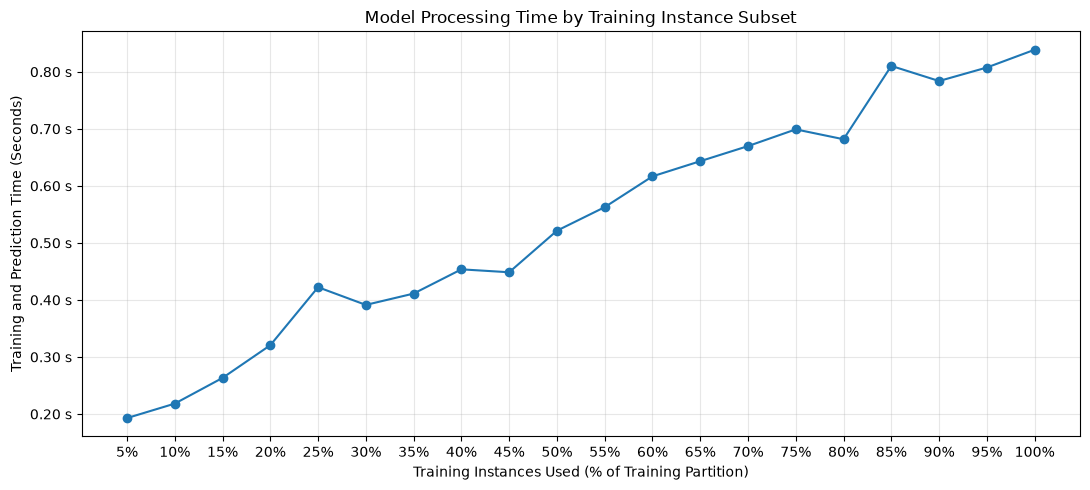

In [110]:
plt.figure(figsize=(11, 5))

plt.plot(
    latest_df["subset"],
    latest_df["duration"],
    marker="o"
)

plt.title("Model Processing Time by Training Instance Subset")
plt.xlabel("Training Instances Used (% of Training Partition)")
plt.ylabel("Training and Prediction Time (Seconds)")

plt.xticks(range(5, 101, 5))
plt.gca().xaxis.set_major_formatter(percent_formatter)
plt.gca().yaxis.set_major_formatter(seconds_formatter)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    DATA_FOLDER / "time_vs_subset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

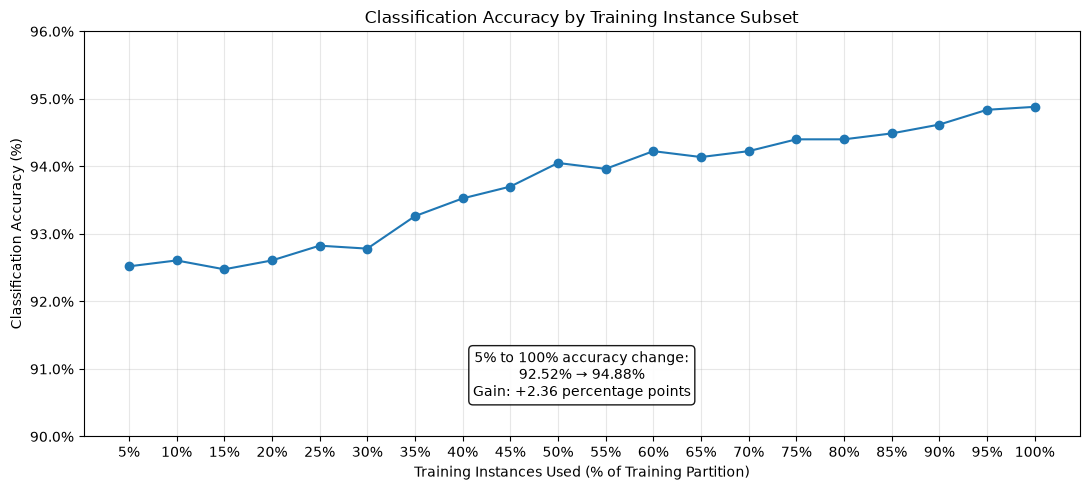

In [111]:
plt.figure(figsize=(11, 5))

plt.plot(
    latest_df["subset"],
    latest_df["accuracy"],
    marker="o"
)

first_row = latest_df[
    latest_df["subset"] == 5
].iloc[0]

last_row = latest_df[
    latest_df["subset"] == 100
].iloc[0]

accuracy_gain = (
    last_row["accuracy"] - first_row["accuracy"]
)

plt.title("Classification Accuracy by Training Instance Subset")
plt.xlabel("Training Instances Used (% of Training Partition)")
plt.ylabel("Classification Accuracy (%)")

plt.xticks(range(5, 101, 5))
plt.gca().xaxis.set_major_formatter(percent_formatter)
plt.gca().yaxis.set_major_formatter(accuracy_formatter)

plt.ylim(90, 96)
plt.grid(True, alpha=0.3)

plt.text(
    0.50,
    0.10,
    (
        f"5% to 100% accuracy change:\n"
        f"{first_row['accuracy']:.2f}% → "
        f"{last_row['accuracy']:.2f}%\n"
        f"Gain: +{accuracy_gain:.2f} percentage points"
    ),
    transform=plt.gca().transAxes,
    ha="center",
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "alpha": 0.9
    }
)

plt.tight_layout()

plt.savefig(
    DATA_FOLDER / "accuracy_vs_subset_annotated.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

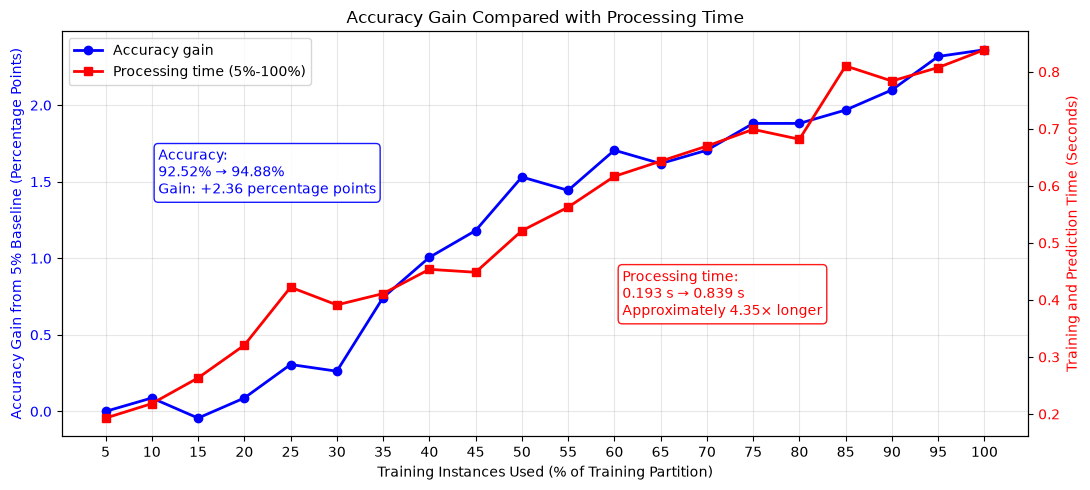

In [112]:
fig, axis1 = plt.subplots(figsize=(11, 5))

# Blue line: accuracy gain
accuracy_line = axis1.plot(
    latest_df["subset"],
    latest_df["accuracy"] - latest_df.iloc[0]["accuracy"],
    marker="o",
    color="blue",
    linewidth=2,
    label="Accuracy gain"
)

axis1.set_xlabel(
    "Training Instances Used (% of Training Partition)"
)

axis1.set_ylabel(
    "Accuracy Gain from 5% Baseline (Percentage Points)",
    color="blue"
)

axis1.tick_params(
    axis="y",
    labelcolor="blue"
)

axis1.set_xticks(range(5, 101, 5))
axis1.grid(True, alpha=0.3)

# Red line: actual processing time in seconds
axis2 = axis1.twinx()

time_line = axis2.plot(
    latest_df["subset"],
    latest_df["duration"],
    marker="s",
    color="red",
    linewidth=2,
    label="Processing time (5%-100%)"
)

axis2.set_ylabel(
    "Training and Prediction Time (Seconds)",
    color="red"
)

axis2.tick_params(
    axis="y",
    labelcolor="red"
)

plt.title(
    "Accuracy Gain Compared with Processing Time"
)

# Combined legend
lines = accuracy_line + time_line
labels = [line.get_label() for line in lines]

axis1.legend(
    lines,
    labels,
    loc="upper left"
)

# Summary boxes
first_row = latest_df.iloc[0]
last_row = latest_df.iloc[-1]

accuracy_gain = (
    last_row["accuracy"] - first_row["accuracy"]
)

axis1.text(
    0.10,
    0.6,
    (
        f"Accuracy:\n"
        f"{first_row['accuracy']:.2f}% → "
        f"{last_row['accuracy']:.2f}%\n"
        f"Gain: +{accuracy_gain:.2f} percentage points"
    ),
    transform=axis1.transAxes,
    color="blue",
    fontsize=10,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "edgecolor": "blue",
        "alpha": 0.9
    }
)

axis1.text(
    0.58,
    0.3,
    (
        f"Processing time:\n"
        f"{first_row['duration']:.3f} s → "
        f"{last_row['duration']:.3f} s\n"
        f"Approximately "
        f"{last_row['duration'] / first_row['duration']:.2f}× longer"
    ),
    transform=axis1.transAxes,
    color="red",
    fontsize=10,
    bbox={
        "boxstyle": "round",
        "facecolor": "white",
        "edgecolor": "red",
        "alpha": 0.9
    }
)

fig.tight_layout()

plt.savefig(
    DATA_FOLDER / "accuracy_gain_vs_processing_seconds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [113]:
selected_percentages = [5, 10, 25, 50, 100]

comparison_df = latest_df[
    latest_df["subset"].isin(selected_percentages)
].copy()

comparison_df["accuracy"] = comparison_df["accuracy"].map(
    lambda value: round(value, 4)
)

comparison_df["duration"] = comparison_df["duration"].map(
    lambda value: round(value, 6)
)

comparison_df = comparison_df.rename(columns={
    "worker": "Worker",
    "subset": "Training Subset (%)",
    "duration": "Processing Time (seconds)",
    "accuracy": "Accuracy (%)"
})

comparison_df

,Worker,Training Subset (%),Processing Time (seconds),Accuracy (%)
0,worker4,5,0.192852,92.5197
1,worker2,10,0.218219,92.6072
4,worker3,25,0.422297,92.8259
9,worker0,50,0.521364,94.0507
19,worker2,100,0.838622,94.8819
